In [ ]:
# 라이브러리 임포트
import numpy as np
import tensorflow as tf
import keras

In [ ]:
# 랜덤 시드 고정
np.random.seed(567)
tf.random.set_seed(567)

In [ ]:
# 데이터 로드
data = np.load('datasets/fashion_mnist.npz')

In [5]:
# 데이터 전처리
(x_train, y_train), (x_test, y_test) = (data['x_train'], data['y_train']), (data['x_test'], data['y_test'])

In [ ]:
# 레이블 정의
labels = {
      0: 'T-shirt/top'
    , 1: 'Trouser'
    , 2: 'Pullover'
    , 3: 'Dress'
    , 4: 'Coat'
    , 5: 'Sandal'
    , 6: 'Shirt'
    , 7: 'Sneaker'
    , 8: 'Bag'
    , 9: 'Ankle boot'
}

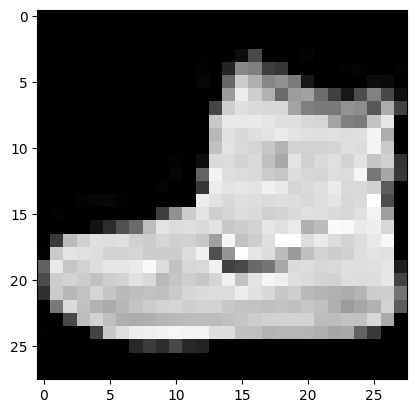

In [ ]:
# 데이터 시각화
import matplotlib.pyplot as plt

# 첫 번째 훈련 샘플 시각화
plt.imshow(x_train[0], cmap=plt.cm.gray)
plt.show()

In [8]:
y_train[0:9]

array([9, 0, 0, 3, 0, 2, 7, 2, 5], dtype=uint8)

In [9]:
# 데이터 형태 확인
x_train.shape

(60000, 28, 28)

In [10]:
# 데이터 차원 변경
x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

In [ ]:
# 데이터 정규화
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test /= 255

In [ ]:
# 레이블 원-핫 인코딩
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

# 첫 번째 훈련 샘플 레이블 확인
y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

# 모델 구성 (압축된 형태)
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, kernel_size=(5, 5), activation='relu', padding='same'), 
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(5, 5), activation='relu', padding='same'), 
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax'),
])

model.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# 콜백 설정
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=False),
    ModelCheckpoint(filepath='best_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [17]:
# 모델 학습
hist = model.fit(x_train, y_train, epochs=500, batch_size=1000, validation_split=0.1, callbacks=callbacks)

Epoch 1/500


54/54 [==============================] - 9s 129ms/step - loss: 0.9223 - accuracy: 0.6926 - val_loss: 0.5686 - val_accuracy: 0.7850
Epoch 2/500
54/54 [==============================] - 6s 109ms/step - loss: 0.4987 - accuracy: 0.8222 - val_loss: 0.4529 - val_accuracy: 0.8328
Epoch 3/500
54/54 [==============================] - 6s 108ms/step - loss: 0.4220 - accuracy: 0.8509 - val_loss: 0.4037 - val_accuracy: 0.8567
Epoch 4/500
54/54 [==============================] - 6s 110ms/step - loss: 0.3833 - accuracy: 0.8648 - val_loss: 0.3828 - val_accuracy: 0.8615
Epoch 5/500
54/54 [==============================] - 6s 108ms/step - loss: 0.3588 - accuracy: 0.8730 - val_loss: 0.3577 - val_accuracy: 0.8717
Epoch 6/500
54/54 [==============================] - 6s 116ms/step - loss: 0.3403 - accuracy: 0.8793 - val_loss: 0.3397 - val_accuracy: 0.8773
Epoch 7/500
54/54 [==============================] - 6s 118ms/step - loss: 0.3222 - accuracy: 0.8857 - val_loss: 0.3288 - val_accuracy: 0.88

In [19]:
# 모델 평가
results = model.evaluate(x_test, y_test, verbose=0)
results

[0.2662307620048523, 0.9125000238418579]

In [ ]:
# 예측
y_preds = model.predict(x_test)
y_preds 

313/313 [==============================] - 2s 6ms/step


array([[4.1606750e-08, 9.3334867e-13, 8.2952063e-08, ..., 3.3663568e-04,
        4.5634149e-08, 9.9961215e-01],
       [1.0384357e-06, 1.4332598e-12, 9.9997973e-01, ..., 4.8837733e-21,
        6.2651655e-16, 3.1421947e-18],
       [8.0387492e-09, 1.0000000e+00, 2.2626531e-11, ..., 3.6010349e-19,
        2.9573951e-11, 6.3864433e-19],
       ...,
       [1.3500975e-06, 4.7053538e-11, 2.7672524e-08, ..., 6.0897642e-10,
        9.9999666e-01, 1.9434383e-17],
       [4.2491322e-07, 9.9999630e-01, 1.2019080e-06, ..., 1.8710867e-13,
        7.5295299e-09, 3.3470983e-11],
       [6.0635316e-04, 2.4694785e-07, 1.0566836e-02, ..., 2.9517755e-01,
        5.8024861e-03, 1.2620522e-04]], dtype=float32)

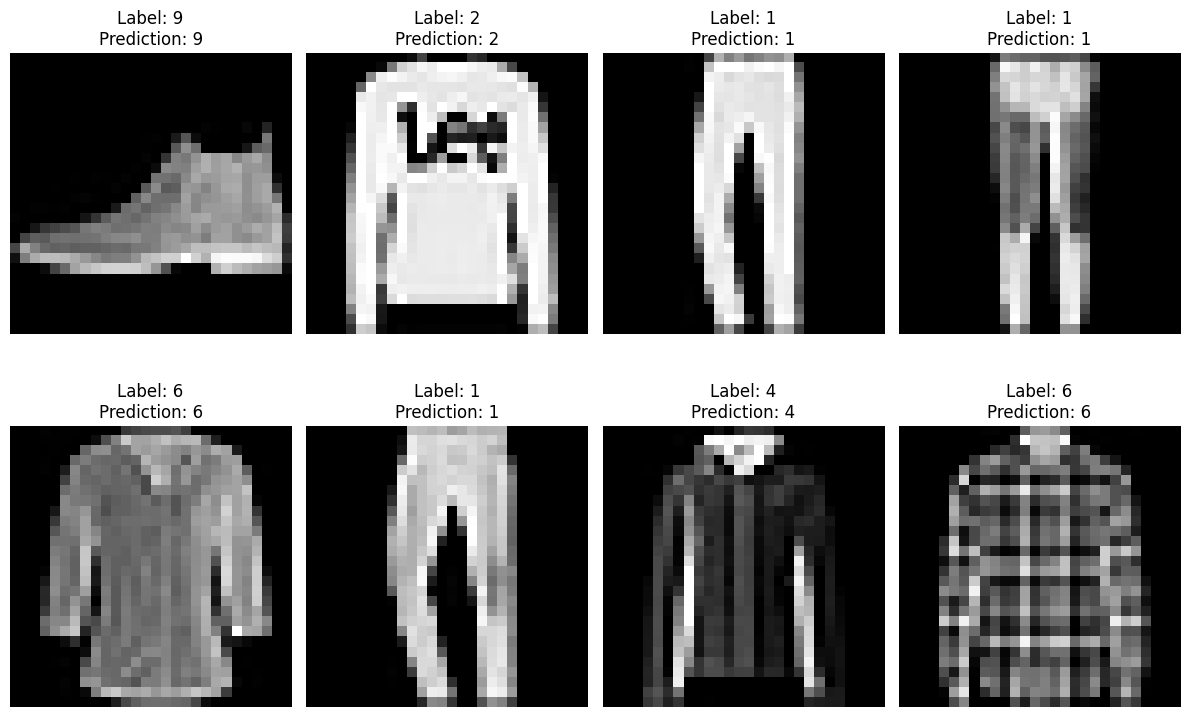

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 라벨 정의 (MNIST라면 0~9)
labels = [str(i) for i in range(10)]

y_test_label = [np.argmax(i) for i in y_test]

plt.figure(figsize=(12,8))

for idx, row in enumerate(x_test[0:8]):
    plt.subplot(2, 4, idx+1)
    plt.title(f'Label: {labels[y_test_label[idx]]}\nPrediction: {labels[y_pred[idx]]}')
    plt.axis('off')
    plt.imshow(row.reshape(28, 28), cmap=plt.cm.gray)

plt.tight_layout()
plt.show()


In [31]:
import os
from tensorflow import keras

# 폴더 생성
os.makedirs("src_ml", exist_ok=True)

# 저장
model.save("src_ml/model.keras")

# 불러오기
new_model = keras.models.load_model("src_ml/model.keras")

# 평가
results = new_model.evaluate(x_test, y_test, verbose=0)
print(results)

[0.2662307620048523, 0.9125000238418579]
